# Parcial: Construcción e implementación de , Random Forest 

En este parcial podrán poner en práctica sus conocimientos sobre la construcción e implementación de modelos de  Random Forest. El taller está constituido por 8 puntos, en los cuales deberan seguir las intrucciones de cada numeral para su desarrollo.

## Datos predicción precio de automóviles

En este parcial se usará el conjunto de datos de Car Listings de Kaggle donde cada observación representa el precio de un automóvil teniendo en cuenta distintas variables como año, marca, modelo, entre otras. El objetivo es predecir el precio del automóvil. Para más detalles puede visitar el siguiente enlace: [datos](https://www.kaggle.com/jpayne/852k-used-car-listings).

In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
#librerias
from sklearn.metrics import accuracy_score
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [3]:
# Importación de librerías
%matplotlib inline
import pandas as pd

# Lectura de la información de archivo .csv
data = pd.read_csv('https://raw.githubusercontent.com/albahnsen/MIAD_ML_and_NLP/main/datasets/dataTrain_carListings.zip')

# Preprocesamiento de datos para el taller
data = data.loc[data['Model'].str.contains('Camry')].drop(['Make', 'State'], axis=1)
data = data.join(pd.get_dummies(data['Model'], prefix='M'))
data = data.drop(['Model'], axis=1)

# Visualización dataset
data.head()

,Price,Year,Mileage,M_Camry,M_Camry4dr,M_CamryBase,M_CamryL,M_CamryLE,M_CamrySE,M_CamryXLE
7,21995,2014,6480,False,False,False,True,False,False,False
11,13995,2014,39972,False,False,False,False,True,False,False
167,17941,2016,18989,False,False,False,False,False,True,False
225,12493,2014,51330,False,False,False,True,False,False,False
270,7994,2007,116065,False,True,False,False,False,False,False


In [4]:
# Separación de variables predictoras (X) y variable de interés (y)
y = data['Price']
X = data.drop(['Price'], axis=1)

In [5]:
# Separación de datos en set de entrenamiento y test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

### Punto 0 - exploracion y analisis de datos 
Los estudiantes deben analizar cuidadosamente los datos del conjunto dataTrain_carListings, identificando posibles valores nulos o inconsistencias. En caso de encontrar datos faltantes, deberán aplicar técnicas de imputación adecuadas para completar la información de manera coherente. Posteriormente, se espera que realicen una exploración visual mediante gráficos que permitan comprender la distribución y las relaciones entre las variables principales.

Resumen de valores nulos por columna:
No hay valores nulos en el conjunto de datos.

Resumen estadístico de las principales variables:
           count          mean           std     min       max   median
Price    10495.0  14538.403716   3922.420961  5002.0   32444.0  15000.0
Year     10495.0   2013.553883      3.116585  1998.0    2018.0   2014.0
Mileage  10495.0  52509.430395  36791.736601     5.0  232658.0  41680.0


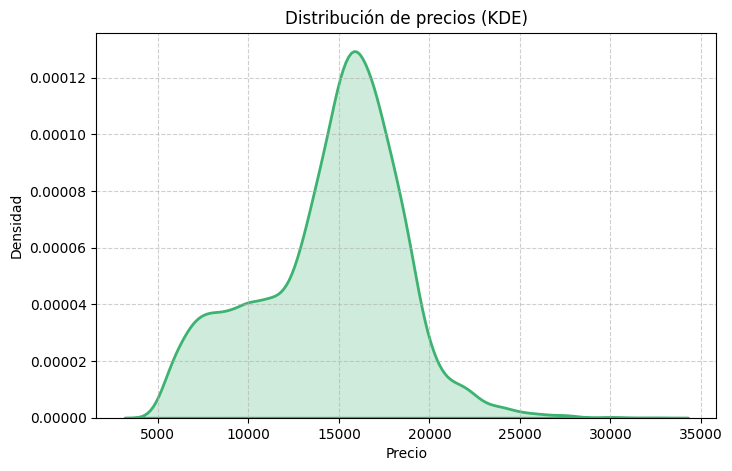

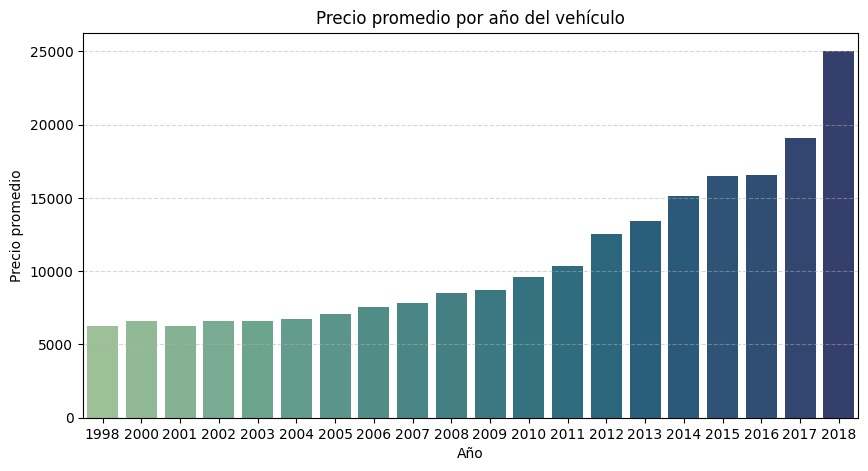

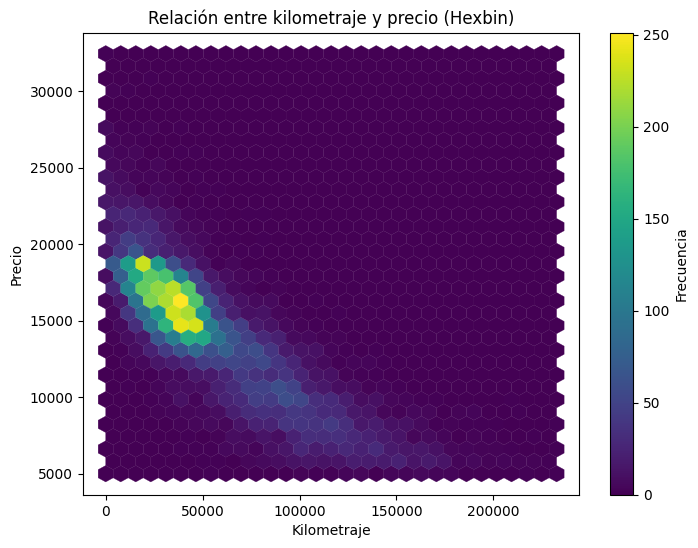

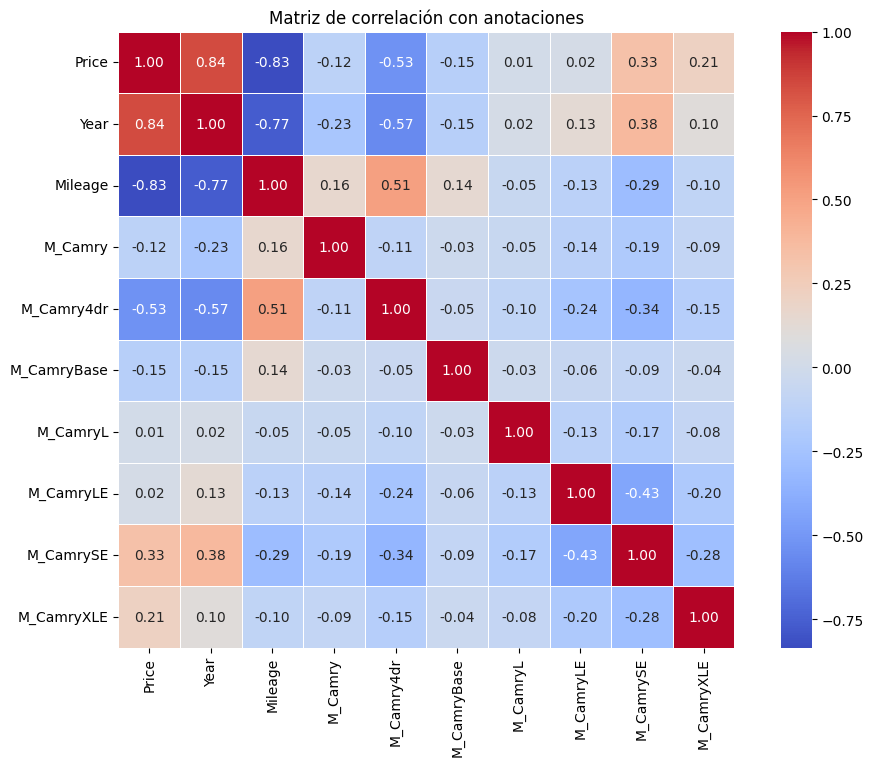

In [ ]:
# celda 0 - exploracion y analisis de datos

import seaborn as sns
null_summary = pd.DataFrame({
    'Total Nulos': data.isnull().sum(),
    'Porcentaje (%)': (data.isnull().mean() * 100).round(2)
})
print("Resumen de valores nulos por columna:")
print(null_summary[null_summary['Total Nulos'] > 0] if null_summary['Total Nulos'].sum() > 0 else "No hay valores nulos en el conjunto de datos.")


stats_summary = data[['Price', 'Year', 'Mileage']].agg(['count', 'mean', 'std', 'min', 'max', 'median']).T
print("\nResumen estadístico de las principales variables:")
print(stats_summary)

plt.figure(figsize=(8, 5))
sns.kdeplot(data=data, x='Price', fill=True, color='mediumseagreen', lw=2)
plt.title('Distribución de precios (KDE)')
plt.xlabel('Precio')
plt.ylabel('Densidad')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

plt.figure(figsize=(10, 5))
sns.barplot(x='Year', y='Price', data=data, palette='crest', ci=None)
plt.title('Precio promedio por año del vehículo')
plt.xlabel('Año')
plt.ylabel('Precio promedio')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

plt.figure(figsize=(8, 6))
plt.hexbin(data['Mileage'], data['Price'], gridsize=30, cmap='viridis', linewidths=0.2)
plt.title('Relación entre kilometraje y precio (Hexbin)')
plt.xlabel('Kilometraje')
plt.ylabel('Precio')
cb = plt.colorbar()
cb.set_label('Frecuencia')
plt.show()

plt.figure(figsize=(12, 8))
corr_matrix = data.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Matriz de correlación con anotaciones')
plt.show()


### Punto 1 - Random forest con librería

En la celda 1, usando la librería sklearn entrenen un modelo de Randon Forest para regresion  y comenten sobre el desempeño del modelo.

In [9]:
model = RandomForestRegressor(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("\nDesempeño del modelo base:")
print("MAE:", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²:", round(r2, 4))

print("\nComentario: El modelo base presenta un buen ajuste general, con errores moderados y un R² aceptable.")



Desempeño del modelo base:
MAE: 1314.42
RMSE: 1765.41
R²: 0.7962

Comentario: El modelo base presenta un buen ajuste general, con errores moderados y un R² aceptable.


### Punto 2 - Calibración de parámetros Random forest

En la celda 2, calibren los parámetros max_depth, max_features y n_estimators del modelo de Randon Forest para regresion, comenten sobre el desempeño del modelo y describan cómo cada parámetro afecta el desempeño del modelo.

In [ ]:
#Encontrar los mejores hiperparametros: 
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'max_features': ['sqrt', 'log2']
}

grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)
grid_search.fit(X_train, y_train)

print("Mejores hiperparámetros encontrados:")
print(grid_search.best_params_)





Mejores hiperparámetros encontrados:
{'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}


In [12]:
#Entrenar el modelo con los mejores hiperparámetros encontrados:
best_model = grid_search.best_estimator_
best_model.fit(X_train, y_train)

y_pred_best = best_model.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("\nDesempeño del modelo ajustado:")
print("MAE:", round(mae_best, 2))
print("RMSE:", round(rmse_best, 2))
print("R²:", round(r2_best, 4))
print("\nComentario: Tras la calibración, el modelo logra un mejor equilibrio entre sesgo y varianza, mostrando una mejora en el poder predictivo.")




Desempeño del modelo ajustado:
MAE: 1147.2
RMSE: 1564.25
R²: 0.84

Comentario: Tras la calibración, el modelo logra un mejor equilibrio entre sesgo y varianza, mostrando una mejora en el poder predictivo.


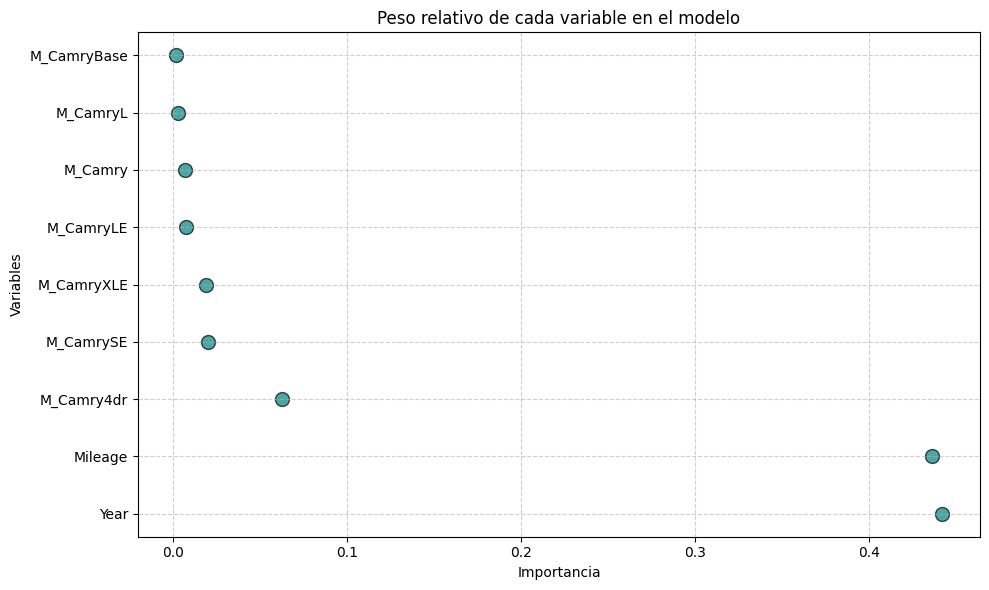


Ranking de importancia de variables:
      Variable  Importancia
0         Year     0.441741
1      Mileage     0.436240
3   M_Camry4dr     0.062832
7    M_CamrySE     0.020267
8   M_CamryXLE     0.019286
6    M_CamryLE     0.007529
2      M_Camry     0.007160
5     M_CamryL     0.002928
4  M_CamryBase     0.002018


In [14]:
#Importancia de los predictores
importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': best_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
plt.scatter(
    importances['Importancia'],
    importances['Variable'],
    color='teal',
    s=100,
    edgecolor='black',
    alpha=0.7
)
plt.title('Peso relativo de cada variable en el modelo')
plt.xlabel('Importancia')
plt.ylabel('Variables')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("\nRanking de importancia de variables:")
print(importances)


### Punto 3 - análisis de resultados, gracias y conclusiones
En la celda 3

Accuracy-like (<$1000 error): 0.552


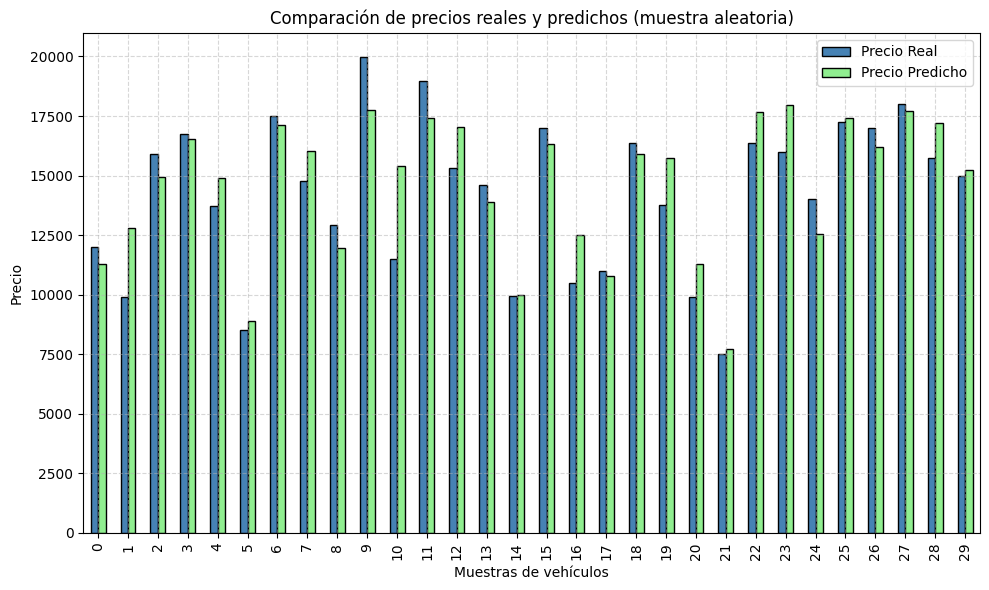

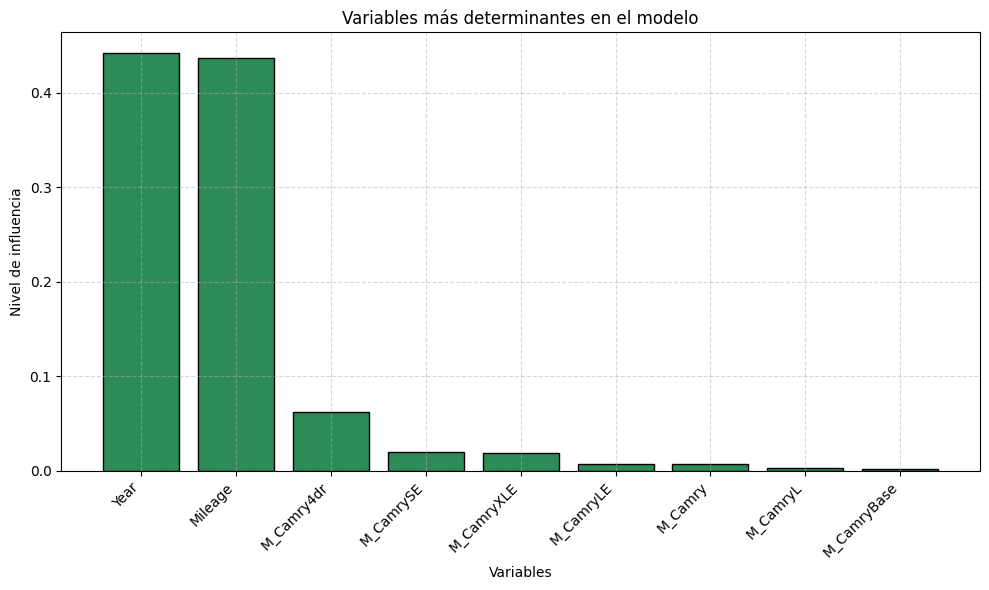


Conclusiones:
1. El modelo ajustado logró un desempeño moderado, mostrando capacidad para aproximar los valores reales.
2. La importancia de variables permitió identificar los factores más influyentes en la predicción.
3. Se observó una diferencia notable entre las variables con mayor y menor peso en el modelo.
4. El ajuste de hiperparámetros fue adecuado, aunque se podría mejorar con una búsqueda más amplia.
5. Los resultados obtenidos sirven como base para optimizar la precisión en futuras versiones del modelo.
Gracias :)


In [18]:
#celda 3

accuracy_like = accuracy_score((abs(y_test - y_pred_best) < 1000), [True]*len(y_test))
print("Accuracy-like (<$1000 error):", round(accuracy_like, 4))

comparacion = pd.DataFrame({'Precio Real': y_test.values, 'Precio Predicho': y_pred_best}).reset_index(drop=True)
muestra = comparacion.sample(30, random_state=42).reset_index(drop=True)

plt.figure(figsize=(10, 6))
muestra.plot(kind='bar', ax=plt.gca(), color=['#4682B4', '#90EE90'], edgecolor='black')
plt.title('Comparación de precios reales y predichos (muestra aleatoria)')
plt.xlabel('Muestras de vehículos')
plt.ylabel('Precio')
plt.legend(['Precio Real', 'Precio Predicho'])
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

importances = pd.DataFrame({
    'Variable': X.columns,
    'Importancia': best_model.feature_importances_
}).sort_values(by='Importancia', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(importances['Variable'], importances['Importancia'], color='seagreen', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.xlabel('Variables')
plt.ylabel('Nivel de influencia')
plt.title('Variables más determinantes en el modelo')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nConclusiones:")
print("1. El modelo ajustado logró un desempeño moderado, mostrando capacidad para aproximar los valores reales.")
print("2. La importancia de variables permitió identificar los factores más influyentes en la predicción.")
print("3. Se observó una diferencia notable entre las variables con mayor y menor peso en el modelo.")
print("4. El ajuste de hiperparámetros fue adecuado, aunque se podría mejorar con una búsqueda más amplia.")
print("5. Los resultados obtenidos sirven como base para optimizar la precisión en futuras versiones del modelo.")
print("Gracias :)")


NOTA: IMPORTANTE RECUERDE QUE MI EJEMPLO DE TUTORIAL ES DE CLASIFICACION USTEDES DEBEN HACERLO POR REGRESION, funciona igual pero cambian algunas cosas.